In [2]:
import os
import os.path as op
from datetime import datetime
from typing import Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyTMD
import timescale
import xarray as xr
from bluemath_tk.topo_bathy.mesh_utils import decode_open_boundary_data, read_adcirc_grd


def extract_pos_nearest_points_regular(
    xds_grid: xr.Dataset,
    lon_points: Union[list, np.ndarray],
    lat_points: Union[list, np.ndarray],
) -> Tuple[int, int]:
    """
    Find the closest grid point indices for given longitude and latitude points.

    Parameters
    ----------
    xds_grid : xr.Dataset
        Dataset containing grid data (lon_z, lat_z, hz).
    lon_points : list or np.ndarray
        Longitudes of interest.
    lat_points : list or np.ndarray
        Latitudes of interest.

    Returns
    -------
    pos_lon_points_mesh : int
        Index of closest longitude grid point.
    pos_lat_points_mesh : int
        Index of closest latitude grid point.

    Notes
    -----
    Converts negative longitudes by adding 360 and uses squared differences to find the nearest grid point.
    Assumes grid is regularly spaced.
    """

    if lon_points < 0:
        lon_points = lon_points + 360

    z = xds_grid.hz.values
    Lon_grid = xds_grid.lon_z.values
    Lat_grid = xds_grid.lat_z.values
    LLat, LLon = np.meshgrid(Lat_grid, Lon_grid)

    Lon_val = LLon[z != 0]
    Lat_val = LLat[z != 0]

    index = np.nanargmin((lat_points - Lat_val) ** 2 + (lon_points - Lon_val) ** 2)

    pos_lon_points_mesh = Lon_val[index]
    pos_lat_points_mesh = Lat_val[index]

    return pos_lon_points_mesh, pos_lat_points_mesh

In [3]:
tini = datetime(2020, 7, 11, 0, 0)
tend = datetime(2020, 7, 11, 17, 0)

In [4]:
tide_dir = "/home/grupos/geocean/faugeree/BlueMath/toolkit/mesh/TOPEX"
TIDE_MODEL = "TPX09_atlas_v4"

model_directory = os.path.join(tide_dir, TIDE_MODEL)
grid_file = "grid_tpxo9_atlas_v4.nc"
model_files = [
    "h_q1_tpxo9_atlas_30_v4.nc",
    "h_o1_tpxo9_atlas_30_v4.nc",
    "h_p1_tpxo9_atlas_30_v4.nc",
    "h_k1_tpxo9_atlas_30_v4.nc",
    "h_n2_tpxo9_atlas_30_v4.nc",
    "h_m2_tpxo9_atlas_30_v4.nc",
    "h_s2_tpxo9_atlas_30_v4.nc",
    "h_k2_tpxo9_atlas_30_v4.nc",
    "h_m4_tpxo9_atlas_30_v4.nc",
    "h_ms4_tpxo9_atlas_30_v4.nc",
    "h_mn4_tpxo9_atlas_30_v4.nc",
    "h_2n2_tpxo9_atlas_30_v4.nc",
    "h_mf_tpxo9_atlas_30_v4.nc",
    "h_mm_tpxo9_atlas_30_v4.nc",
]

grid_file = os.path.join(model_directory, grid_file)
model_file = [os.path.join(model_directory, m) for m in model_files]

model_format = "netcdf"
TYPE = "z"
SCALE = 1.0 / 1000.0

days_calc = (tend - tini).total_seconds() / 86400

In [3]:
gr3_path = "../outputs/Santona_mesh_adcirc.grd"
Nodes, Elmts, lines = read_adcirc_grd(gr3_path)

In [6]:
xds_grid = xr.open_dataset(grid_file)
lon_TOPEX, lat_TOPEX = extract_pos_nearest_points_regular(
    xds_grid, np.mean(Nodes[:, 1]), np.mean(Nodes[:, 2])
)
amp, ph, D, c = pyTMD.io.ATLAS.extract_constants(
    lon_TOPEX,
    lat_TOPEX,
    grid_file,
    model_file,
    TYPE=TYPE,
    METHOD="spline",
    GZIP=False,
    SCALE=SCALE,
)

Text(0.5, 1.0, 'Boundary condition')

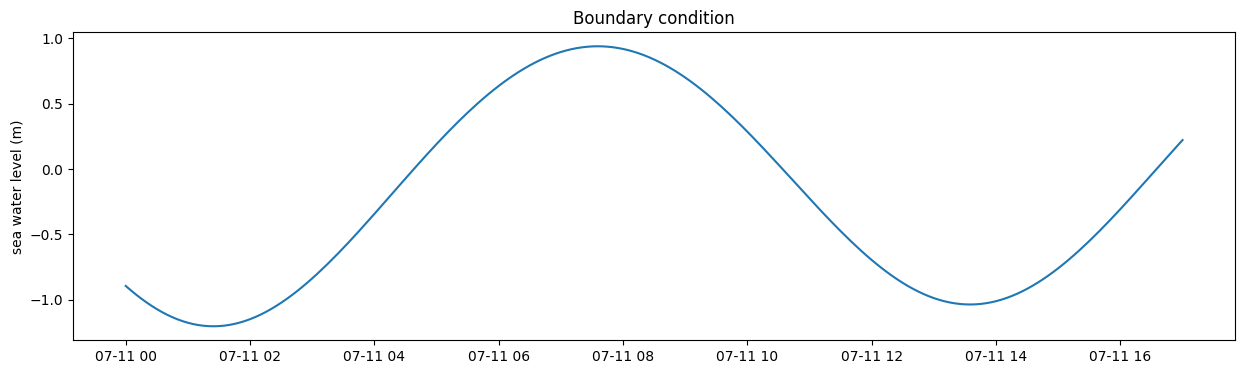

In [7]:
# calculate complex phase in radians for Euler's
cph = -1j * ph * np.pi / 180.0

# calculate constituent oscillation
hc = amp * np.exp(cph)

time_range = pd.date_range(start=tini, end=tend, freq="5min")
time_range_s = (time_range - time_range[0]).total_seconds()
ts = timescale.from_datetime(time_range)

TIDE = pyTMD.predict.time_series(
    ts.tide, hc, c, deltat=ts.tt_ut1, corrections=model_format
)
MINOR = pyTMD.predict.infer_minor(
    ts.tide, hc, c, deltat=ts.tt_ut1, corrections=model_format
)

TIDE += MINOR
fig, (axs) = plt.subplots(nrows=1, ncols=1, figsize=[15, 4])
plt.plot(time_range, TIDE.data)
axs.set_ylabel("sea water level (m)")
axs.set_title("Boundary condition")

In [8]:
boundary_info = decode_open_boundary_data(lines)
longest_boundary_key = max(boundary_info, key=lambda k: len(boundary_info[k]))
longest_boundary_values = boundary_info[longest_boundary_key]

In [9]:
obs_coordinates = [
    (-3.4283760, 43.340149),
    (-3.4547800, 43.388186),
]

In [15]:
rt_exe = "templates"

with open(op.join(rt_exe, "bctides.in"), "w") as file_bctides:
    file_bctides.write("!metamodel\n0 40. ntip\n0 nbfr\n")
    file_bctides.write(f"1 nope\n{len(longest_boundary_values)} 1 0 0 0")

with open(op.join(rt_exe, "vgrid.in"), "w") as file_vgrid:
    file_vgrid.write(
        "2 !ivcor\n2 1 1.e6\nZ levels\n1 -1.e6\nS levels\n40. 1. 1.e-4\n1 -1.\n2 0."
    )  # for 2D grid

with open(op.join(rt_exe, "station.in"), "w") as file_station:
    file_station.write(
        f"1 0 0 0 0 0 1 1 0\n{len(obs_coordinates)}    !number of stations\n"
    )
    for i in range(len(obs_coordinates)):
        file_station.write(
            f"{i + 1}	{obs_coordinates[i][0]}	{obs_coordinates[i][1]}	-1\n"
        )

with open(op.join(rt_exe, "elev.th"), "w") as file_elev:
    for i in range(len(time_range_s)):
        file_elev.write(f"{time_range_s[i]} {TIDE.data[i]}\n")
    file_elev.write("\n")

In [11]:
from bluemath_tk.wrappers.schism.schism_wrapper import SchismModelWrapper

In [12]:
metamodel_parameters = {
    # Most important parameters ex MA-LI sheme
    "indvel": [1],
    "ihorcon": [0],
    "ishapiro": [0],
    "inter_mom": [0],
    # CORE
    "ipre": [0],  # Pre-process flag
    "ibc": [0],  # Baroclinic
    "ibtp": [0],  # Baroclinic
    "rnday": [days_calc],  # total simulation time (day)
    "dt": [5],  # timestem (s)
    # WWM
    "msc2": [24],
    "mdc2": [30],
    # Number of tracer
    "ntracer_gen": [2],
    "ntracer_age": [4],
    "sed_class": [5],
    "eco_class": [27],
    # output
    "nspool": [360],  # save each nspol * dt
    "ihfskip": [518400],  # Number of times that it save the Time step (dt) in each file
    # Start time
    "start_year": [tini.year],
    "start_month": [tini.month],
    "start_day": [tini.day],
    "start_hour": [tini.hour],
    "utc_start": [8],  # time zone
    "ics": [2],  # Coordinate system 2 = lon/lat
    "ieos_type": [0],  # UNESCO 1980 (nonlinear); =1: linear function of T ONLY, i.e.
    "ieos_pres": [0],  # without pressure effects
    "eos_a": [-0.1],  # needed if ieos_type=1; should be <=0
    "eos_b": [1001],  # needed if ieos_type=1
    # outputs
    "output_WL": [1],
    "output_wind_velocity": [0],
    "output_water_temperature": [0],
    "output_depth_averaged_vel": [1],
    "output_water_salinity": [0],
}

In [16]:
output_dir = "CASES"
templates_dir = "templates"

schism_wrapper = SchismModelWrapper(
    templates_dir=templates_dir,
    metamodel_parameters=metamodel_parameters,
    fixed_parameters={},
    output_dir=output_dir,
)

# Build the input files
schism_wrapper.build_cases(
    mode="one_by_one",
)

2025-09-03 08:14:08,726 - SchismModelWrapper - WARNING - Parameter indvel is not in the default_parameters
2025-09-03 08:14:08,727 - SchismModelWrapper - WARNING - Parameter ihorcon is not in the default_parameters
2025-09-03 08:14:08,727 - SchismModelWrapper - WARNING - Parameter ishapiro is not in the default_parameters
2025-09-03 08:14:08,727 - SchismModelWrapper - WARNING - Parameter inter_mom is not in the default_parameters
2025-09-03 08:14:08,728 - SchismModelWrapper - WARNING - Parameter ipre is not in the default_parameters
2025-09-03 08:14:08,728 - SchismModelWrapper - WARNING - Parameter ibc is not in the default_parameters
2025-09-03 08:14:08,728 - SchismModelWrapper - WARNING - Parameter ibtp is not in the default_parameters
2025-09-03 08:14:08,729 - SchismModelWrapper - WARNING - Parameter rnday is not in the default_parameters
2025-09-03 08:14:08,729 - SchismModelWrapper - WARNING - Parameter dt is not in the default_parameters
2025-09-03 08:14:08,730 - SchismModelWrappe

In [14]:
# TODO: Change launchSchism.sh by your working executable file!

schism_wrapper.run_cases(launcher="launchSchism.sh")

2025-09-03 08:10:46,567 - SchismModelWrapper - ERROR - Error running command: launchSchism.sh
2025-09-03 08:10:46,568 - SchismModelWrapper - ERROR - Error: Command 'launchSchism.sh' returned non-zero exit status 2.
